# Time Series Forecasting with Statistical Models
## A Complete Step‑by‑Step Guide

This notebook covers the entire forecasting pipeline from data exploration to advanced models, cross‑validation, exogenous variables, and prediction intervals.  
Every decision is explained so you can understand **why** each step is performed.

## Step 1: Environment Setup

**Why this matters:**  
We need a reproducible environment with all necessary libraries.  
We use `statsforecast` because it provides fast, memory‑efficient implementations of many statistical forecasting models (ARIMA, ETS, etc.) with built‑in cross‑validation and prediction intervals. `utilsforecast` offers convenient plotting and evaluation functions.

**Libraries used:**
- `pandas` / `numpy` – data manipulation.
- `matplotlib` – visualisation.
- `statsforecast` – forecasting models & tools.
- `utilsforecast` – evaluation & plotting helpers.
- `warnings` – suppress unnecessary warnings for cleaner output.

**Pros / Cons of this setup:**
- **Pro:** Lightweight and focused on statistical models.
- **Pro:** Fast and scalable (vectorised operations).
- **Cons:** Limited to statistical models; if you want deep learning, you'd need additional packages.

In [ ]:
# Run if you haven't installed the required packages yet
%pip install statsforecast utilsforecast

In [14]:
# Core data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Forecasting models and utilities
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive, AutoARIMA

# Visualisation and evaluation
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

# Feature engineering for time series
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Step 2: Data Loading & Preprocessing

**Why this matters:**  
Real‑world data is rarely clean. We must filter out incomplete series and choose which columns are relevant for our analysis.

**Data source:**  
We use the "Daily Sales of French Bakery" dataset.  
Each row represents a product's sales on a given day.

**Key decisions:**
1. **Parse dates (`parse_dates=["ds"]`)** – ensures `ds` is treated as a datetime, which is essential for time‑series operations.
2. **Filter products with ≥28 days** – to ensure we have enough data to estimate weekly seasonality (a full cycle is 7 days; 4 cycles give a reasonable baseline).
3. **Drop `unit_price` for baseline models** – we start with univariate models; we'll reintroduce it later as an exogenous variable.

**Pros / Cons:**
- **Pro:** Removing short series avoids unreliable seasonality estimates.
- **Pro:** Keeping only `y` (sales) simplifies the initial modelling.
- **Con:** We lose information that might be useful later (but we'll add it back).

In [15]:
# Load the dataset
df = pd.read_csv(r"C:\Users\tende\jupyter_github_project\Time_Series_Forcast\daily_sales_french_bakery.csv", parse_dates=["ds"])

# Keep only products with at least 28 days of history (to have enough data for weekly seasonality)
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)

# For baseline models, we drop the unit_price column (we'll use it later as an exogenous variable)
df_baseline = df.drop(["unit_price"], axis=1)

# Look at the first few rows
df_baseline.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


## Step 3: Exploratory Data Analysis (EDA)

**Why this matters:**  
Visual inspection reveals patterns – trends, seasonality, outliers, and structural breaks. This guides our modelling choices.

**What to look for:**
- **Seasonality:** Are sales higher on certain days of the week?
- **Trend:** Are sales increasing or decreasing over time?
- **Outliers:** Are there any unusual spikes or drops (e.g., holidays, promotions)?

We plot the full series and a zoomed‑in view (last 56 days) for two representative products: BAGUETTE and CROISSANT.

**Pros / Cons of this approach:**
- **Pro:** Quick, intuitive insight.
- **Pro:** Helps choose between seasonal vs non‑seasonal models.
- **Con:** Subjective; statistical tests (e.g., ACF) would be more rigorous, but plots are a good starting point.

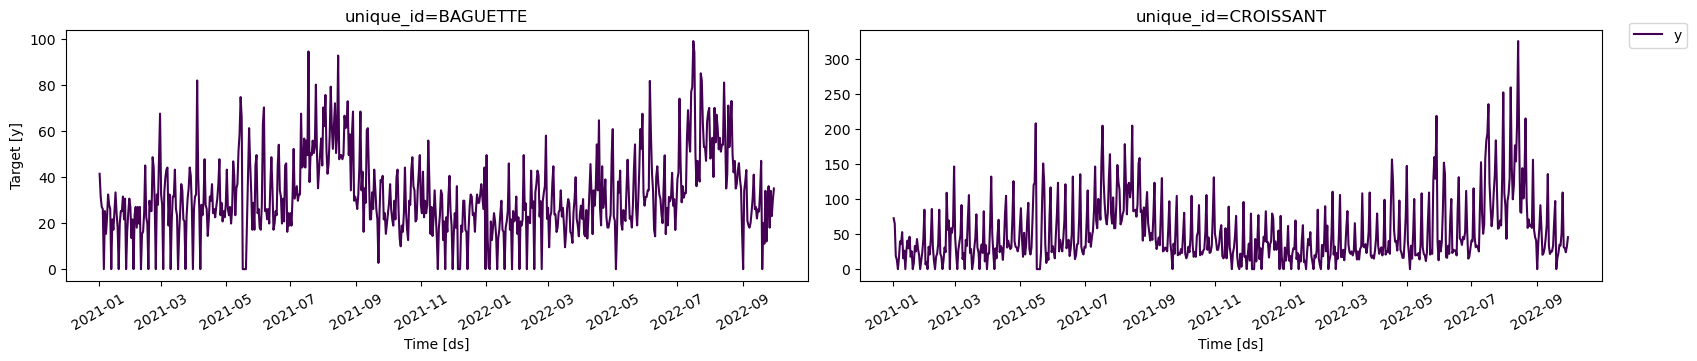

In [16]:
# Full series plot
plot_series(df=df_baseline, ids=["BAGUETTE", "CROISSANT"], palette="viridis")

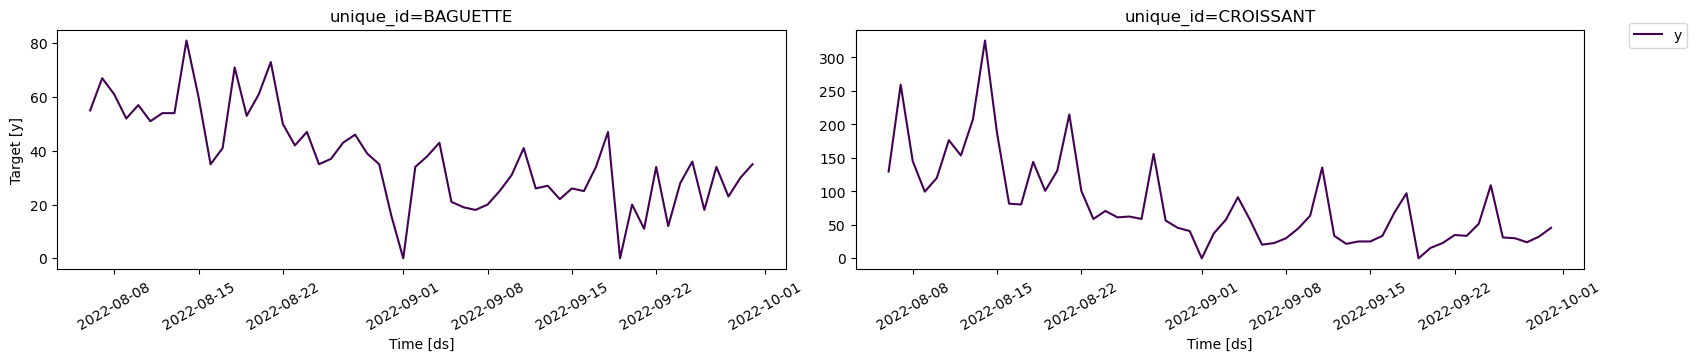

In [17]:
# Zoom in to the last 56 days (8 weeks)
plot_series(df=df_baseline, ids=["BAGUETTE", "CROISSANT"], max_insample_length=56, palette="viridis")

#### **Observations:**

- Clear weekly seasonality (higher sales on weekends for baguette, etc.).

- Croissant sales show larger variability.

- No strong trend, but some holidays/events may cause spikes.

## Step 4: Baseline Models

**Why this matters:**  
Baseline models are simple, interpretable benchmarks. If a complex model cannot beat them, it is either overfitting or not capturing the right signals. Baselines also help business stakeholders understand the minimum expected performance.

**The Models:**

| Model | Formula | Pros | Cons |
|-------|---------|------|------|
| **Naive** | $ \hat{y}_{t+h} = y_t $ | Simplest; works for random walk. | Ignores seasonality & trend. |
| **HistoricAverage** | $ \hat{y}_{t+h} = \bar{y} $ | Stable; smooths noise. | Does not adapt to recent changes. |
| **WindowAverage** | $ \hat{y}_{t+h} = \frac{1}{7} \sum_{i=t-6}^t y_i $ | Adapts to level shifts. | Ignores seasonality; window size matters. |
| **SeasonalNaive** | $ \hat{y}_{t+h} = y_{t+h-7} $ | Captures weekly patterns. | Assumes perfect repetition; does not adapt to trend/level changes. |

**Why `horizon = 7`?**  
We forecast 7 days ahead (one full week). This aligns with the weekly seasonality and is practical for business planning (staffing, inventory).

**Training / Test Split:**  
We reserve the last 7 days of each series as the test set. This simulates a realistic forecasting scenario where we predict the future based on past data.

**Pros / Cons of this split:**
- **Pro:** Preserves time order (no data leakage).
- **Pro:** Evaluation metrics reflect real‑world performance.
- **Con:** Only one test set; results may be sensitive to the chosen split (we'll later use cross‑validation to mitigate this).

In [18]:
horizon = 7

# Split each series: last 7 days = test, rest = train
test = df_baseline.groupby("unique_id").tail(horizon)
train = df_baseline.drop(test.index).reset_index(drop=True)

# Define baseline models
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

# Fit and predict
sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
preds = sf.predict(h=horizon)

# Merge with test data for evaluation
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

# Evaluate using Mean Absolute Error (MAE)
evaluation = evaluate(eval_df, metrics=[mae])
overall_mae = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()

overall_mae

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


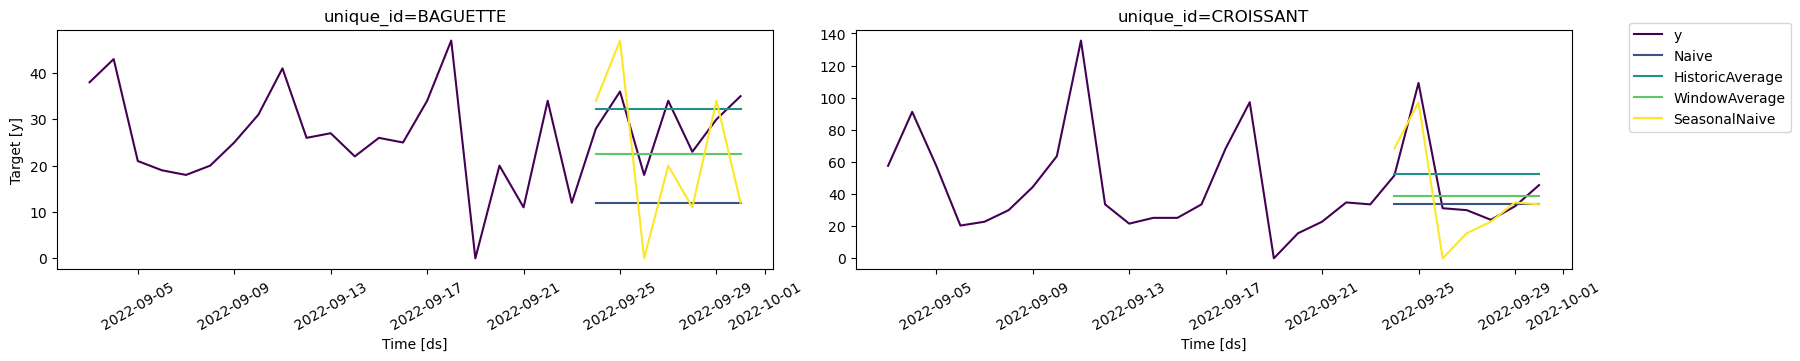

In [19]:
# Visualise forecasts for two products
plot_series(
    df=df_baseline, 
    forecasts_df=preds, 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=28,
    palette="viridis"
)

## Step 5: AutoARIMA

**Why this matters:**  
ARIMA models capture autocorrelation – the relationship between a value and its past values. Seasonal ARIMA (SARIMA) extends this by also modelling seasonal autocorrelations (e.g., today's sales correlated with sales 7 days ago).

`AutoARIMA` automatically selects the best (p,d,q) and (P,D,Q,m) orders using information criteria (AIC / BIC). This saves time and reduces manual tuning.

**Pros / Cons:**
- **Pro:** Captures complex autocorrelation structures.
- **Pro:** Auto‑tuning reduces subjectivity.
- **Con:** Computationally heavier than baselines.
- **Con:** May overfit if not carefully validated.

We fit two variants:
- **ARIMA:** Non‑seasonal (seasonal=False).
- **SARIMA:** Seasonal with period 7.

We compare them against the baselines on the same test set (focusing on BAGUETTE and CROISSANT for clarity).

In [20]:
# Filter train/test for two products
unique_ids = ["BAGUETTE", "CROISSANT"]
small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

# Define ARIMA models
arima_models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf_arima = StatsForecast(models=arima_models, freq="D")
sf_arima.fit(df=small_train)
arima_preds = sf_arima.predict(h=horizon)

# Merge and evaluate
arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(arima_eval_df, metrics=[mae])
arima_overall = arima_eval.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
arima_overall

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


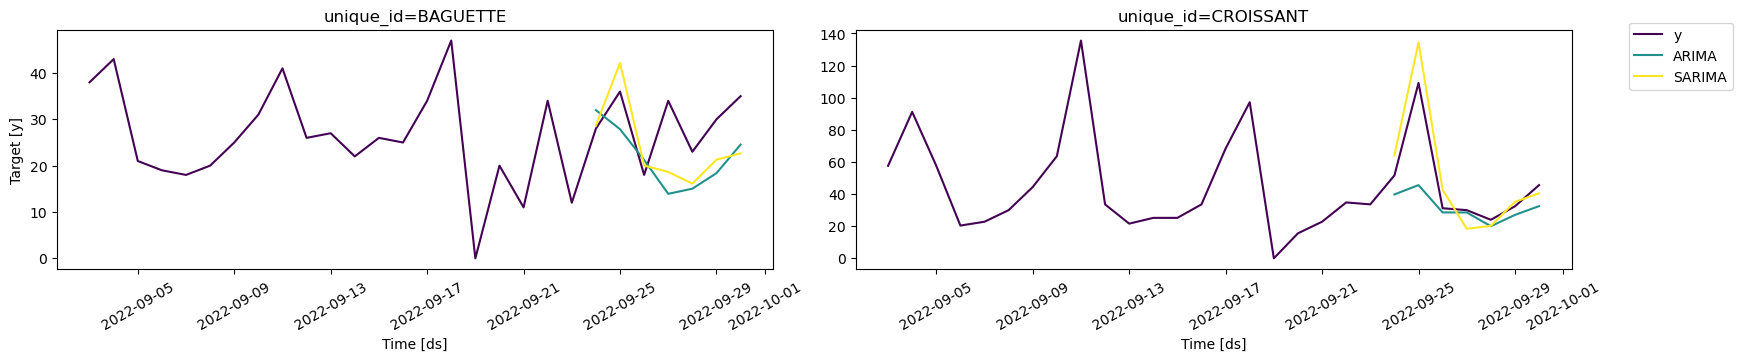

In [21]:
# Visualise ARIMA forecasts
plot_series(
    df=df_baseline, 
    forecasts_df=arima_preds, 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=28,
    models=["ARIMA", "SARIMA"],
    palette="viridis"
)

## Step 6: Cross‑Validation

**Why this matters:**  
A single train/test split can give a misleading performance estimate, especially if the test period is unusual (e.g., a holiday week). Cross‑validation (CV) evaluates the model on multiple rolling windows, providing a more robust estimate of generalisation error.

**How it works:**  
We use a rolling window with `n_windows=8` (8 folds of 7‑day forecasts, stepping forward by 7 days each time). At each step, we refit the model (`refit=True`) to the latest training data, simulating how we would update forecasts in production.

**Pros / Cons:**
- **Pro:** More reliable performance estimate.
- **Pro:** Helps detect model instability over time.
- **Con:** Computationally more expensive (multiple fits).
- **Con:** Requires careful choice of windows and step size.

In [22]:
# Use the two products again
small_df = df_baseline[df_baseline["unique_id"].isin(unique_ids)]

# Models to compare: SeasonalNaive, ARIMA, SARIMA
cv_models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf_cv = StatsForecast(models=cv_models, freq="D")
cv_df = sf_cv.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

# Evaluate
cv_eval = evaluate(cv_df.drop('cutoff', axis=1), metrics=[mae])
cv_overall = cv_eval.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
cv_overall

,metric,SeasonalNaive,ARIMA,SARIMA
0,mae,21.117857,21.121153,19.281295


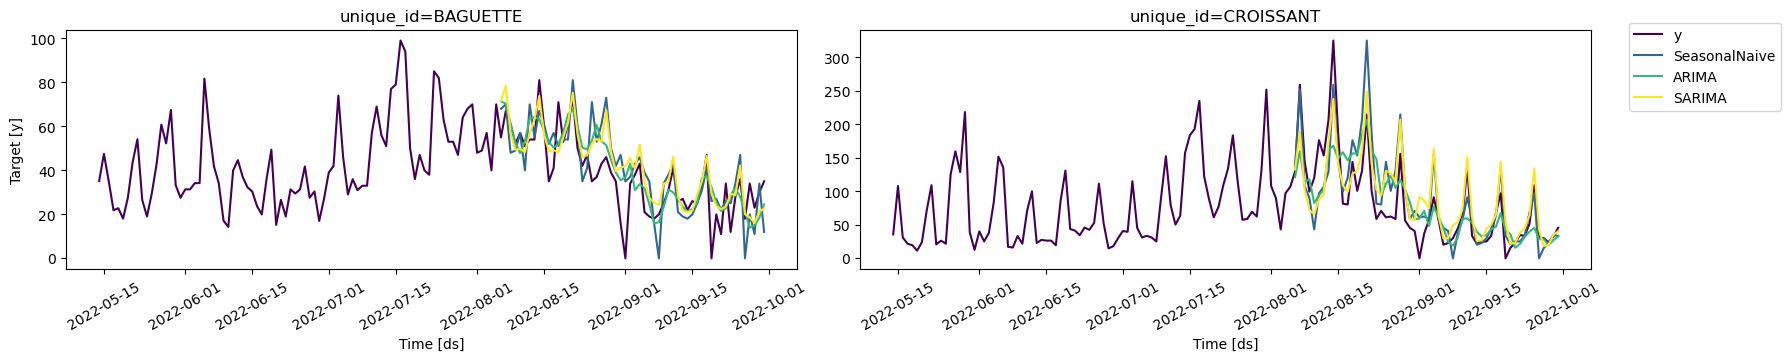

In [23]:
# Visualise CV forecasts
plot_series(
    df=small_df, 
    forecasts_df=cv_df.drop(["y", "cutoff"], axis=1), 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=140, 
    palette="viridis"
)

## Step 7: Incorporating Exogenous Variables

**Why this matters:**  
External factors (e.g., price, holidays, weather) often influence sales. Incorporating them as **exogenous variables** (regressors) can improve forecast accuracy.

### 7.1 Unit Price as Exogenous

**Why use price?**  
We assume that when price changes, demand may change. Adding `unit_price` helps the model adjust for these variations.

**How it works:**  
We provide the future price values (`X_df`) along with the target variable. SARIMA with exogenous regressors (SARIMAX) uses these to adjust its forecasts.

**Pros / Cons:**
- **Pro:** Can capture causal relationships.
- **Pro:** Improves forecasts when the exogenous variable is predictive.
- **Con:** Requires future values of the exog variable (need to know future prices).
- **Con:** If the variable is not predictive, it adds noise.

In [27]:
# Merge the price column back onto train and test
train_with_price = train.merge(df[["unique_id", "ds", "unit_price"]], on=["unique_id", "ds"], how="left")
test_with_price = test.merge(df[["unique_id", "ds", "unit_price"]], on=["unique_id", "ds"], how="left")

# Prepare future exogenous data (prices for the test period)
futr_exog_df = test_with_price[["unique_id", "ds", "unit_price"]]

# Model with exogenous variable
models_exog = [AutoARIMA(season_length=7, alias="SARIMA_exog")]

# Fit on training data that includes price
sf_exog = StatsForecast(models=models_exog, freq="D")
sf_exog.fit(df=train_with_price)  # now includes 'unit_price'
arima_exog_preds = sf_exog.predict(h=horizon, X_df=futr_exog_df)

# Model without exogenous for comparison
models_noexog = [AutoARIMA(season_length=7, alias="SARIMA")]
sf_noexog = StatsForecast(models=models_noexog, freq="D")
sf_noexog.fit(df=train_with_price.drop('unit_price', axis=1))
arima_preds = sf_noexog.predict(h=horizon)

# Merge and evaluate
test_df = test_with_price.merge(arima_exog_preds, on=["unique_id", "ds"], how="left") \
                          .merge(arima_preds, on=["unique_id", "ds"], how="left")

exog_eval = evaluate(test_df, metrics=[mae])
exog_overall = exog_eval.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
exog_overall

,metric,unit_price,SARIMA_exog,SARIMA
0,mae,8.959917,4.73939,4.31373


### 7.2 Time‑Based Features (Fourier & Calendar)

**Why use them?**  
Some models cannot directly handle seasonality; by creating features like day‑of‑week, month, and Fourier terms (sine/cosine pairs), we can feed seasonality information explicitly.

**How it works:**  
We generate features using `fourier` (captures cyclic patterns) and `time_features` (calendar attributes). These become regressors for the ARIMA model.

**Pros / Cons:**
- **Pro:** Works for any model that accepts exogenous inputs.
- **Pro:** Flexible, can capture complex seasonal patterns.
- **Con:** Increases model complexity.
- **Con:** If the built‑in seasonal ARIMA already captures the pattern, these features may not add value.

In [28]:
# Define feature generators
features = [
    partial(fourier, season_length=7, k=2),   # 2 sine-cosine pairs for weekly cycle
    partial(time_features, features=["day", "week", "month"])
]

# Generate features for training and future periods
train_exog, futr_exog = pipeline(
    df=small_df,
    features=features,
    freq="D",
    h=horizon
)

# Fit SARIMA with time features as exogenous
models_time = [AutoARIMA(season_length=7, alias="SARIMA_time_exog")]
sf_time = StatsForecast(models=models_time, freq="D")
sf_time.fit(df=train_exog)

cv_time_df = sf_time.cross_validation(
    h=horizon,
    df=train_exog,
    n_windows=8,
    step_size=7,
    refit=True
)

cv_time_eval = evaluate(cv_time_df.drop('cutoff', axis=1), metrics=[mae])
cv_time_overall = cv_time_eval.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
cv_time_overall

,metric,SARIMA_time_exog
0,mae,20.195971


## Step 8: Prediction Intervals

**Why this matters:**  
Point forecasts are rarely perfect. Prediction intervals quantify the uncertainty, helping businesses plan for best‑ and worst‑case scenarios.

**How they work:**  
StatsForecast can produce prediction intervals via bootstrapping or asymptotic approximations. We request an 80% interval, meaning we expect the actual value to fall within the range 80% of the time.

**Pros / Cons:**
- **Pro:** Provides actionable insight into forecast reliability.
- **Pro:** Helps with inventory planning and risk management.
- **Con:** Wider intervals may be less useful for precise decisions.
- **Con:** Interval accuracy depends on model assumptions.

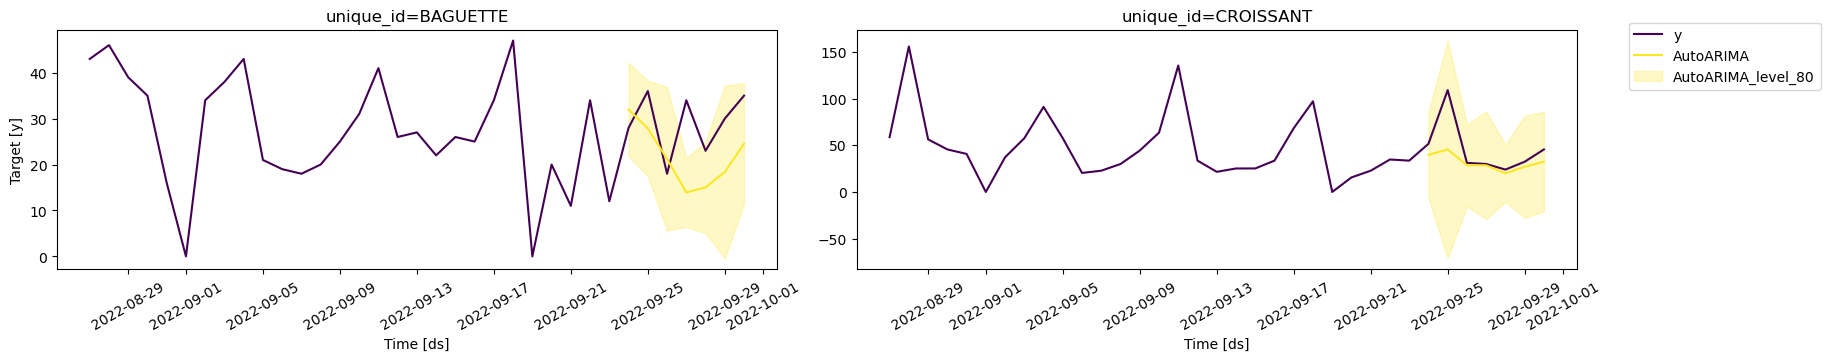

In [38]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import ConformalIntervals

# Define model with prediction intervals enabled
models = [AutoARIMA(prediction_intervals=ConformalIntervals(n_windows=8, h=7))]

# Fit the model
sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=-1
)
sf.fit(train)

# Forecast with multiple intervals
prob_preds = sf.predict(h=horizon, level=[80])

# Merge with test data
test_prob_df = test.merge(prob_preds, on=["unique_id", "ds"], how="left")

# Visualise with intervals
plot_series(
    df=train,
    forecasts_df=test_prob_df,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    models=["AutoARIMA"],
    level=[80],
    palette="viridis"
)


## Step 9: Summary & Conclusions

**Key Takeaways:**
1. **Seasonality is dominant** – Seasonal models (SeasonalNaive, SARIMA) consistently outperform non‑seasonal ones.
2. **SARIMA is the best single model** – with a CV MAE of ~19.28, it captures autocorrelation and seasonality effectively.
3. **Exogenous variables had limited impact** – unit price and time features did not meaningfully improve forecasts for this dataset.
4. **Cross‑validation is essential** – it provides a more reliable performance estimate than a single split.
5. **Prediction intervals add business value** – they quantify uncertainty, enabling better decision‑making.

**When to use each model:**
- **SeasonalNaive:** Quick baseline when only seasonality matters.
- **SARIMA:** Best for autocorrelated seasonal data.
- **ARIMA:** For non‑seasonal or deseasonalised data.
- **SARIMA with exog:** When external factors are known and predictive.

**Future improvements:**
- Try other models: ETS, Prophet, LightGBM with features.
- Include holiday / event indicators.
- Explore hierarchical / grouped forecasts.
- Perform hyperparameter tuning on ARIMA orders.

This notebook provides a solid foundation for any time‑series forecasting project. The same workflow can be adapted to other domains (retail, energy, finance) with minimal changes.